In [6]:
pip install geopy

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib.inline

UsageError: Line magic function `%matplotlib.inline` not found.


In [3]:
data = pd.read_csv('nyc_taxi_trip_duration.csv')

In [5]:
data.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1080784,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,N,400
1,id0889885,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,N,1100
2,id0857912,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,N,1635
3,id3744273,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,N,1141
4,id0232939,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,N,848


In [6]:
data.dtypes

id                     object
vendor_id               int64
pickup_datetime        object
dropoff_datetime       object
passenger_count         int64
pickup_longitude      float64
pickup_latitude       float64
dropoff_longitude     float64
dropoff_latitude      float64
store_and_fwd_flag     object
trip_duration           int64
dtype: object

In [7]:
data.nunique()

id                    729322
vendor_id                  2
pickup_datetime       709359
dropoff_datetime      709308
passenger_count            9
pickup_longitude       19729
pickup_latitude        39776
dropoff_longitude      27892
dropoff_latitude       53579
store_and_fwd_flag         2
trip_duration           6296
dtype: int64

In [8]:
data.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

* Data does not have any null values 

#### Converting data columns into appropriate data types 

In [10]:
data['pickup_datetime'] = pd.DatetimeIndex(data['pickup_datetime'])
data['dropoff_datetime'] = pd.DatetimeIndex(data['dropoff_datetime'])

In [11]:
pickup = pd.DatetimeIndex(data['pickup_datetime'])
dropoff = pd.DatetimeIndex(data['dropoff_datetime'])

In [12]:
data['pickup_dow'] = pickup.day_name()
data['pickup_moy'] = pickup.month
data['pickup_date'] = pickup.strftime('%d')
data['pickup_hour'] = pickup.hour
data['pickup_min'] = pickup.minute

In [13]:
data['dropoff_dow'] = dropoff.day_name()
data['dropoff_moy'] = dropoff.month
data['dropoff_date'] = dropoff.strftime('%d')
data['dropoff_hour'] = dropoff.hour
data['dropoff_min'] = dropoff.minute

In [14]:
def time_of_day(x):
    if x in range(6,12):
        return 'Morning'
    elif x in range(12,16):
        return 'Afternoon'
    elif x in range(16,22):
        return 'Evening'
    else: 
        return 'Late night'

In [15]:
data['pickup_time_of_day'] = data['pickup_hour'].apply(time_of_day)
data['dropoff_time_of_day'] = data['dropoff_hour'].apply(time_of_day)

In [16]:
data['pickup_time_of_day'] = data['pickup_time_of_day'].astype('category')
data['dropoff_time_of_day'] = data['dropoff_time_of_day'].astype('category')

In [17]:
data.dtypes

id                             object
vendor_id                       int64
pickup_datetime        datetime64[ns]
dropoff_datetime       datetime64[ns]
passenger_count                 int64
pickup_longitude              float64
pickup_latitude               float64
dropoff_longitude             float64
dropoff_latitude              float64
store_and_fwd_flag             object
trip_duration                   int64
pickup_dow                     object
pickup_moy                      int64
pickup_date                    object
pickup_hour                     int64
pickup_min                      int64
dropoff_dow                    object
dropoff_moy                     int64
dropoff_date                   object
dropoff_hour                    int64
dropoff_min                     int64
pickup_time_of_day           category
dropoff_time_of_day          category
dtype: object

In [23]:
data['store_and_fwd_flag'] = data['store_and_fwd_flag'].astype('category')
data['id'] = data['id'].astype('category')
data['vendor_id'] = data['vendor_id'].astype('category')
data['passenger_count'] = data['passenger_count'].astype('int64')
data['pickup_dow'] = data['pickup_dow'].astype('category')
data['dropoff_dow'] = data['dropoff_dow'].astype('category')

In [19]:
data['pickup_date'] = data['pickup_date'].astype('int64')
data['dropoff_date'] = data['dropoff_date'].astype('int64')

In [20]:
data.drop(['pickup_datetime','dropoff_datetime'],axis= 1, inplace = True)

In [21]:
from geopy.distance import geodesic as GD

def calculate_distance(data):
    pickup_coords = (data['pickup_latitude'], data['pickup_longitude'])
    dropoff_coords = (data['dropoff_latitude'], data['dropoff_longitude'])
    return GD(pickup_coords, dropoff_coords).km


In [22]:
data['Distance'] = data.apply(calculate_distance, axis=1)

In [26]:
data.dtypes

id                     category
vendor_id              category
passenger_count           int64
pickup_longitude        float64
pickup_latitude         float64
dropoff_longitude       float64
dropoff_latitude        float64
store_and_fwd_flag     category
trip_duration             int64
pickup_dow             category
pickup_moy                int64
pickup_date               int64
pickup_hour               int64
pickup_min                int64
dropoff_dow            category
dropoff_moy               int64
dropoff_date              int64
dropoff_hour              int64
dropoff_min               int64
pickup_time_of_day     category
dropoff_time_of_day    category
Distance                float64
dtype: object

In [54]:
data.head()

,id,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_dow,...,pickup_hour,pickup_min,dropoff_dow,dropoff_moy,dropoff_date,dropoff_hour,dropoff_min,pickup_time_of_day,dropoff_time_of_day,Distance
0,id1080784,2,1,-73.953918,40.778873,-73.963875,40.771164,N,400,Monday,...,16,40,Monday,2,29,16,47,Evening,Evening,1.199770
1,id0889885,1,2,-73.988312,40.731743,-73.994751,40.694931,N,1100,Friday,...,23,35,Friday,3,11,23,53,Late night,Late night,4.123945
2,id0857912,2,2,-73.997314,40.721458,-73.948029,40.774918,N,1635,Sunday,...,17,59,Sunday,2,21,18,26,Evening,Evening,7.250436
3,id3744273,2,6,-73.961670,40.759720,-73.956779,40.780628,N,1141,Tuesday,...,9,44,Tuesday,1,5,10,3,Morning,Morning,2.358287
4,id0232939,1,1,-74.017120,40.708469,-73.988182,40.740631,N,848,Wednesday,...,6,42,Wednesday,2,17,6,56,Morning,Morning,4.328155


### Univariate Analysis

* Categorical Columns: vendor_id,store_and_fwd_flag, pickup_dow, dropoff_dow, pickup_time_of_day, dropoff_time_of_day
* Discrete Columns: passenger_count, pickup_moy, dropoff_moy, pickup_hour, dropoff_hour
* Continuous Columns: Distance, trip_duration


In [30]:
categorical_columns = ['vendor_id','store_and_fwd_flag', 'pickup_dow', 'dropoff_dow', 'pickup_time_of_day', 'dropoff_time_of_day']
discrete_columns = ['passenger_count', 'pickup_moy', 'dropoff_moy', 'pickup_hour', 'dropoff_hour']
continuous_columns = ['Distance', 'trip_duration','pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude']

In [46]:
Continuous = data.select_dtypes(['float64'])
Continuous.dtypes

pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
Distance             float64
dtype: object

In [41]:
## Anslysing following continuous variables 

pickup_location = ['pickup_latitude','pickup_longitude']
dropoff_location = ['dropoff_latitude','dropoff_longitude']
Dis_time = ['Distance','trip_duration']

In [47]:
def Uni_Conti(data,var):
    
    size = len(var)
    plt.figure(figsize=(7*size,4))
    
    for j,i in enumerate(var):
        
        maxi = round(data[i].max(),2)
        mini = round(data[i].min(),2)
        rani = round(maxi - mini,2)
        meani = round(data[i].mean(),2)
        mediani = round(data[i].median(),2)
        std_dev = round(data[i].std(),2)
        skewi = round(data[i].skew(),2)
        kurt = round(data[i].kurtosis(),2)
        
        points = round(meani-std_dev,2), round(meani+std_dev,2)
        
        plt.subplot(1,size,j+1)
        sns.kdeplot(x=data[i],fill=True)
        sns.lineplot(x=points, y=[0,0], color = 'black', label = "within 1 std_dev")
        sns.scatterplot(x=[mini,maxi], y=[0,0], color = 'orange', label = f"min&max={mini}&{maxi}")
        sns.scatterplot(x=[meani], y=[0], color = 'red', label = f"mean={meani}")
        sns.scatterplot(x=[mediani], y=[0], color = 'blue', label = f"median={mediani}")
        plt.xlabel(f'{i}', fontsize = 20)
        plt.ylabel('density')
        plt.title(f'within 1 std_dev={points[0]} to {points[1]};kurtosis={kurt};\n skew = {skewi};range = {rani}')


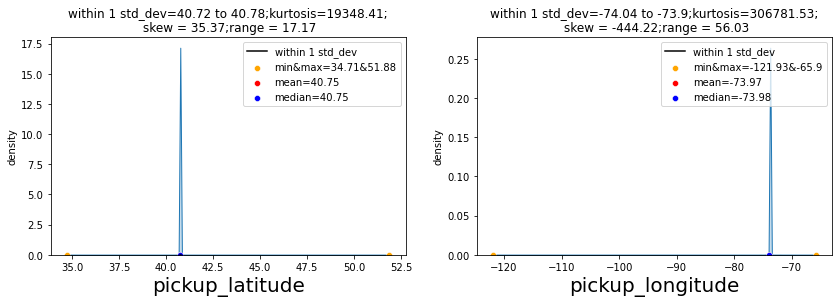

In [43]:
Uni_Conti(data,pickup_location)

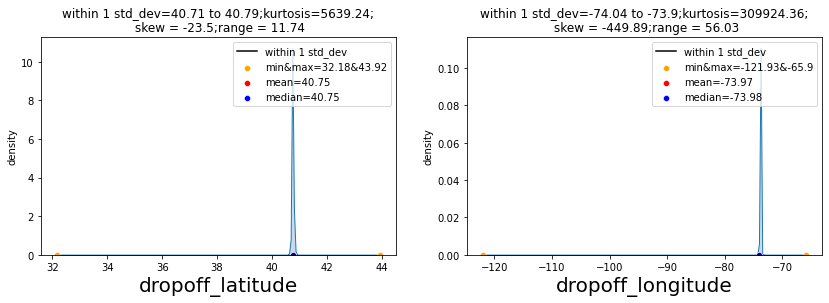

In [48]:
Uni_Conti(data,dropoff_location)

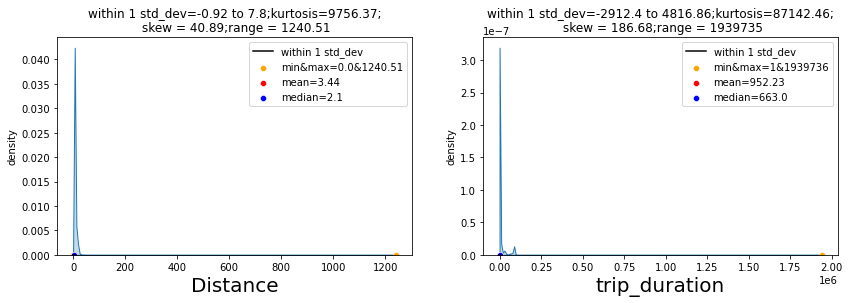

In [49]:
Uni_Conti(data,Dis_time)

In [94]:
data[data['trip_duration'] == data['trip_duration'].max() ]

,id,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_dow,...,pickup_hour,pickup_min,dropoff_dow,dropoff_moy,dropoff_date,dropoff_hour,dropoff_min,pickup_time_of_day,dropoff_time_of_day,Distance
259437,id0593332,2,1,-73.781952,40.644688,-73.993874,40.745926,N,86391,Tuesday,...,13,0,Wednesday,6,1,13,0,Afternoon,Afternoon,21.147722


In [95]:
data[data['Distance'] == data['Distance'].max() ]

,id,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_dow,...,pickup_hour,pickup_min,dropoff_dow,dropoff_moy,dropoff_date,dropoff_hour,dropoff_min,pickup_time_of_day,dropoff_time_of_day,Distance
244913,id2306955,1,1,-72.809669,51.881084,-73.987228,40.750599,N,792,Saturday,...,18,58,Saturday,5,7,19,12,Evening,Evening,1240.510256


* Distance:
    * Distance has range from 0 km to 1240 km with mean distance as 3.4 km.This indiactes presence of outliers in the data.
    * The kde plot indicates the plot is highly right or positively skewed. 
    * There are 2901 trips with 0 distance travelled.This can be a result of:
        * Cancelled trips from drivers or passengers 
        * Failure in recording trip 
    * We can furthur analyse the trips with 0 distance in bivariate analysis.
* Trip duration:
    * Trip duration ranges from 1 sec to 1939736 sec with mean 952.2 sec and median 663 sec. This indicates presence of ouliers in the data.
    * data is positively skewed.
    * Trip duration of 1 sec indicates that either trip was cancelled or not recorded which needs furthur investigation
    

#### Univariate Analysis:Outliers

In [99]:
Distance_duration = ['Distance','trip_duration']

* Drop the entry with high trip_duration to get better visualization

In [87]:
data.drop(data[data['trip_duration'] >= 1900000].index,inplace=True)

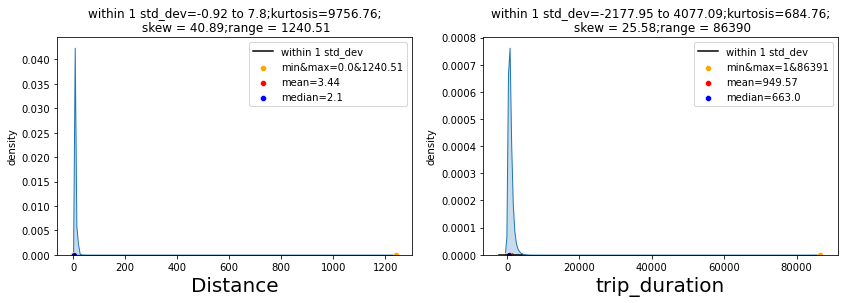

In [88]:
Uni_Conti(data,Dis_time)

In [105]:
def UVA_outlier(data, var_group, include_outlier = True):
    
    size = len(var_group)
    plt.figure(figsize = (7*size,4), dpi = 100)

    #looping for each variable
    for j,i in enumerate(var_group):

        # calculating descriptives of variable
        quant25 = round(data[i].quantile(0.25), 2)
        quant75 = round(data[i].quantile(0.75), 2)
        IQR = round(quant75 - quant25, 2)
        med = round(data[i].median(), 2)
        whis_low = quant25-(1.5*IQR)
        whis_high = quant75+(1.5*IQR)

        # Calculating Number of Outliers
        outlier_high = len(data[i][data[i]>whis_high])
        outlier_low = len(data[i][data[i]<whis_low])

        if include_outlier == True:
            #Plotting the variable with every information
            plt.subplot(1,size,j+1)
            sns.boxplot(data=data[i], orient="v")
            plt.ylabel(f'{i}')
            plt.title(f'With Outliers\nIQR = {IQR}; Median = {med}\n 1st,3rd quartile = {quant25, quant75};\n Outliers(low/high) = {(outlier_low,outlier_high)}')
      
        else:
            # replacing outliers with max/min whisker
            data2 = data[var_group][:]
            data2[i][data2[i]>whis_high] = whis_high+1
            data2[i][data2[i]<whis_low] = whis_low-1

            # plotting without outliers
            plt.subplot(1,size,j+1)
            sns.boxplot(data=data2[i], orient="v")
            plt.ylabel(f'{i}')
            plt.title(f'With Outliers\nIQR = {IQR}; Median = {med}\n 1st,3rd quartile = {quant25, quant75}')

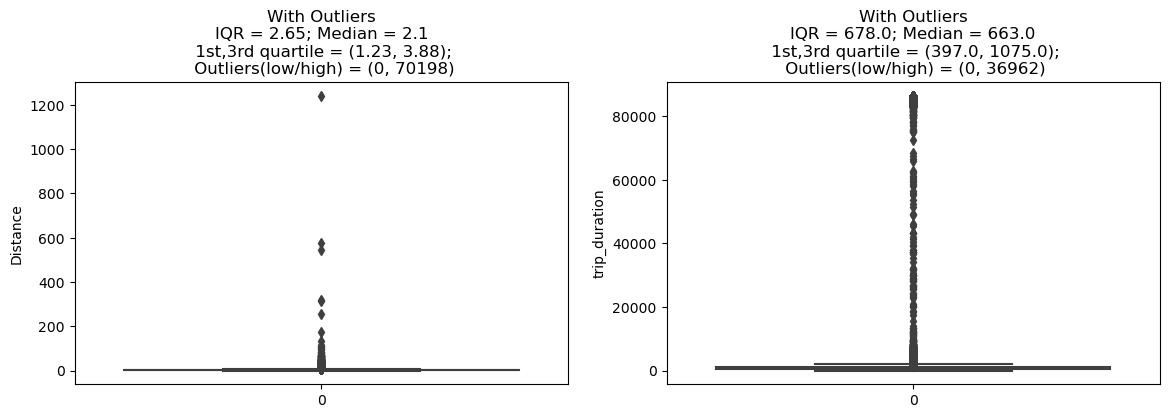

In [106]:
UVA_outlier(data, Distance_duration, include_outlier = True)

* It is difficult to analyze the distribution of data due to presence of outliers. 
* To analyse the data properly we can ignore the outliers from the data using above function. 

C:\Users\user\AppData\Local\Temp/ipykernel_13028/2164670887.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2[i][data2[i]<whis_low] = whis_low-1
C:\Users\user\AppData\Local\Temp/ipykernel_13028/2164670887.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2[i][data2[i]<whis_low] = whis_low-1


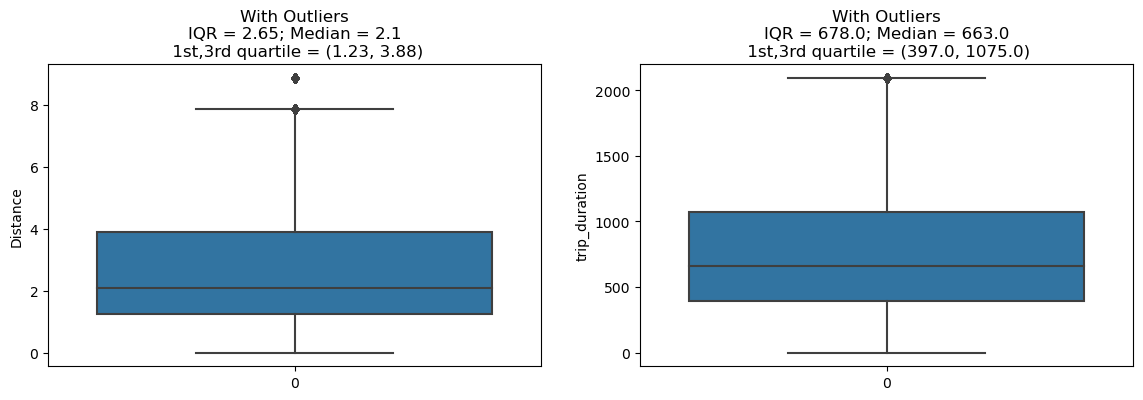

In [109]:
UVA_outlier(data, Distance_duration, include_outlier = False)

## Univariate Analysis: Categorical & Discrete Variables

In [127]:
day = ['pickup_dow','dropoff_dow']
month = ['pickup_moy','dropoff_moy']
hour = ['pickup_hour','dropoff_hour']
time = ['pickup_time_of_day','dropoff_time_of_day']
trip = ['vendor_id','store_and_fwd_flag']

In [128]:
def Uni_Cat(data,var):
    
    size =len(var)
    plt.figure(figsize=(7*size,6))
    
    for j,i in enumerate(var):
        
        n_norm = data[i].value_counts(normalize=True)
        
        plt.subplot(1,size,j+1)
        ax = sns.barplot(y = n_norm,x=n_norm.index)
        for p in ax.patches:
            ax.annotate('{:.4f}'.format(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_y() + p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points',)
        plt.title(f'{i}', fontsize = 15)

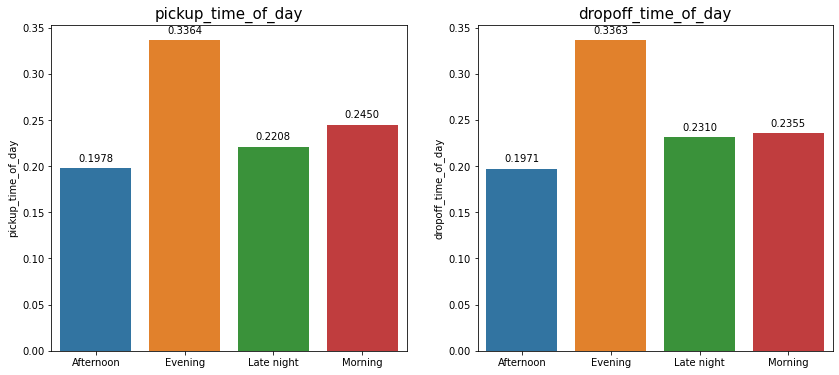

In [129]:
Uni_Cat(data,time)

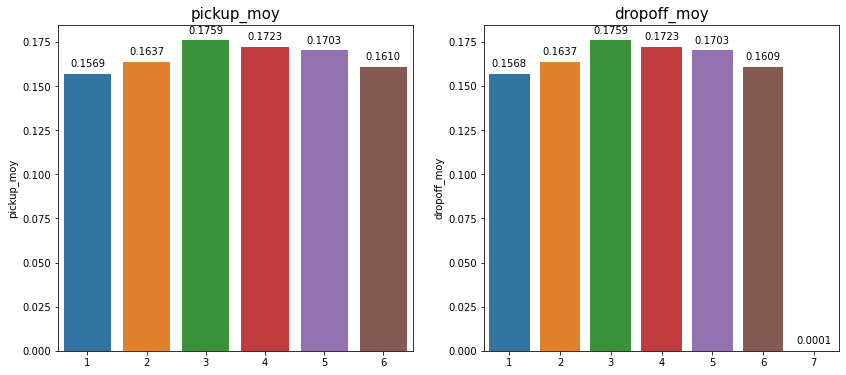

In [130]:
Uni_Cat(data,month)

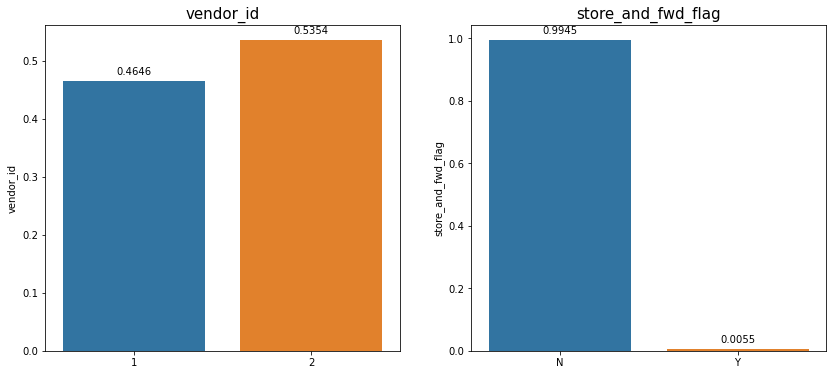

In [131]:
Uni_Cat(data,trip)

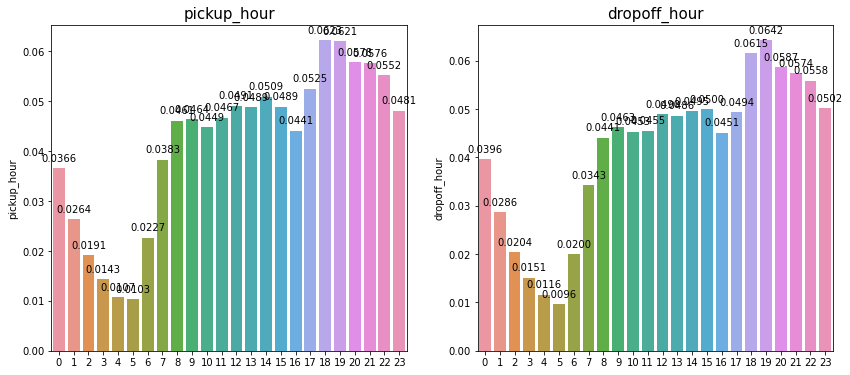

In [132]:
Uni_Cat(data,hour)

* Day_of_week:
    * It is observed that the number of pickups and dropoffs on Fridays and Saturdays are highest. This can be due to following weekends. 
* Time_of_day:
    * The number of trips during Evening times are highest due to home rides of office working passengers.4
    * More than 33% of pickup as well as dropoff trips are booked in the evening. 
* Month_of_year:
    * For dropoff month 7 seems to be extension of pickup trips of 6th month and hence have low value.
* Vendor_id:
    * trips from 2nd vendor are higher than first,
* Store_flag:
    * Maximum number of trips are recorded in real time with vehicle connected to server while some of them have stored the data. 

#### Furthur Analysis:


* Trip duration per hour
* Trip duration per weekday
* Trip duration per month
* Trip duration per vendor
* Trip duration v/s Flag
* Distance per hour
* Distance per weekday
* Distance per month
* Distance per vendor
* Distance v/s Flag
* Distance v/s Trip duration
* Speed per hour
* Speed per weekday
* Passengers per vendor

## Bivariate Analysis: Continuous- Continuous 

In [84]:
Numeric = data.select_dtypes(['int64','float64'])
Numeric.dtypes

pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
trip_duration          int64
pickup_moy             int64
pickup_date            int64
pickup_hour            int64
pickup_min             int64
dropoff_moy            int64
dropoff_date           int64
dropoff_hour           int64
dropoff_min            int64
Distance             float64
dtype: object

* **Correlation** and **Heatmap**

In [85]:
correlation = Numeric.corr()
correlation

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,pickup_moy,pickup_date,pickup_hour,pickup_min,dropoff_moy,dropoff_date,dropoff_hour,dropoff_min,Distance
pickup_longitude,1.000000,0.047648,0.780649,0.118472,0.041561,0.004043,-0.001374,0.010762,-0.003696,0.004096,-0.001536,1.117182e-02,-1.917578e-03,0.251679
pickup_latitude,0.047648,1.000000,0.119972,0.479358,-0.044442,-0.000172,-0.006373,0.011424,0.002838,-0.000240,-0.006363,1.805920e-02,7.303935e-04,-0.128605
dropoff_longitude,0.780649,0.119972,1.000000,0.149598,0.025331,0.003884,-0.000293,-0.022014,-0.003605,0.003923,-0.000378,-2.319331e-02,-2.504285e-03,0.132434
dropoff_latitude,0.118472,0.479358,0.149598,1.000000,-0.035451,-0.000579,-0.006081,0.014259,0.002801,-0.000620,-0.006110,1.817335e-02,-5.076340e-04,-0.153792
trip_duration,0.041561,-0.044442,0.025331,-0.035451,1.000000,0.012861,0.002261,0.005488,-0.004527,0.013798,0.000979,4.082423e-03,-5.622095e-03,0.152177
pickup_moy,0.004043,-0.000172,0.003884,-0.000579,0.012861,1.000000,-0.014998,-0.003305,-0.000331,0.999937,-0.015088,-4.013595e-03,-1.194474e-03,0.016586
pickup_date,-0.001374,-0.006373,-0.000293,-0.006081,0.002261,-0.014998,1.000000,-0.001702,-0.001370,-0.014638,0.997917,-1.826039e-03,-1.506579e-03,0.005142
pickup_hour,0.010762,0.011424,-0.022014,0.014259,0.005488,-0.003305,-0.001702,1.000000,-0.003544,-0.003048,-0.001556,9.345925e-01,-2.756920e-03,-0.016271
pickup_min,-0.003696,0.002838,-0.003605,0.002801,-0.004527,-0.000331,-0.001370,-0.003544,1.000000,-0.000138,-0.001220,-5.842459e-03,1.148377e-01,-0.007428
dropoff_moy,0.004096,-0.000240,0.003923,-0.000620,0.013798,0.999937,-0.014638,-0.003048,-0.000138,1.000000,-0.015437,-4.386421e-03,-1.386263e-03,0.016764


C:\Users\user\anaconda3\lib\site-packages\scipy\stats\stats.py:4812: RuntimeWarning: overflow encountered in longlong_scalars
  (2 * xtie * ytie) / m + x0 * y0 / (9 * m * (size - 2)))


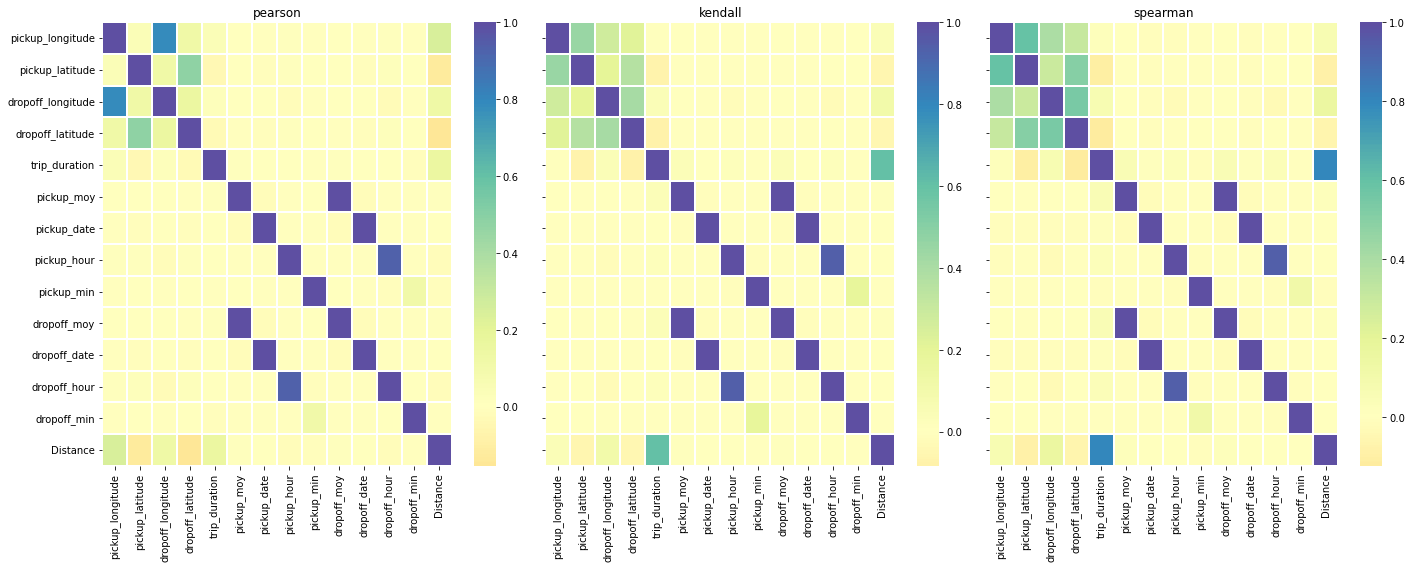

In [86]:
correlations = ['pearson','kendall','spearman']
fig, axes = plt.subplots(1, 3, figsize=(20,8), sharey='all')
for i, ax in enumerate(axes.ravel()):
    sns.heatmap(Numeric.corr(method=correlations[i]), linewidths=2, cmap='Spectral', center=0, ax=ax)
    axes[i].set_title(correlations[i])
plt.tight_layout()

In [87]:
pickup_location = ['pickup_latitude','pickup_longitude']
dropoff_location = ['dropoff_latitude','dropoff_longitude']
Dis_time = ['Distance','trip_duration','passenger_count']
pickup_time = ['pickup_dow', 'pickup_hour','pickup_moy']
dropoff_time = ['dropoff_dow', 'dropoff_hour', 'dropoff_moy']

In [88]:
#sns.pairplot(Numeric[pickup_location])

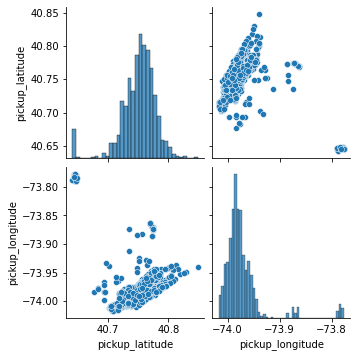

In [89]:
sns.pairplot(Numeric[pickup_location].sample(1000))

### Analysing Discrete against Continuous Data 

def pointplot_plt(data, var, trip_duration):
    plt.figure(figsize=(15, 5))
    size = len(var)

    for j, i in enumerate(var, start=1):
        plt.subplot(1, size, j)
        sns.pointplot(x=data[i], y=data[trip_duration])
        plt.title('Point plot of {} against trip duration'.format(i))
        plt.xlabel(i)
        plt.ylabel(trip_duration)

    plt.tight_layout()
    plt.show()


pointplot_plt(data,pickup_time,trip_Duration)

In [164]:
def point_plt(data, var):
    plt.figure(figsize=(15, 5))
    size = len(var)

    for j, i in enumerate(var, start=1):
        plt.subplot(1, size, j)
        sns.pointplot(x=i, y='trip_duration', data=data)
        plt.title(f'Trip Duration vs {i}')
        plt.xlabel(i)
        plt.ylabel('Trip Duration')

    plt.tight_layout()
    plt.show()

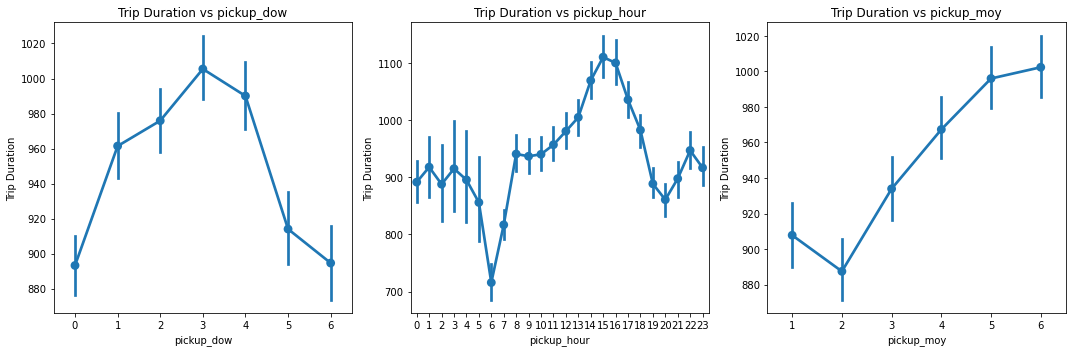

In [165]:
point_plt(data,pickup_time)

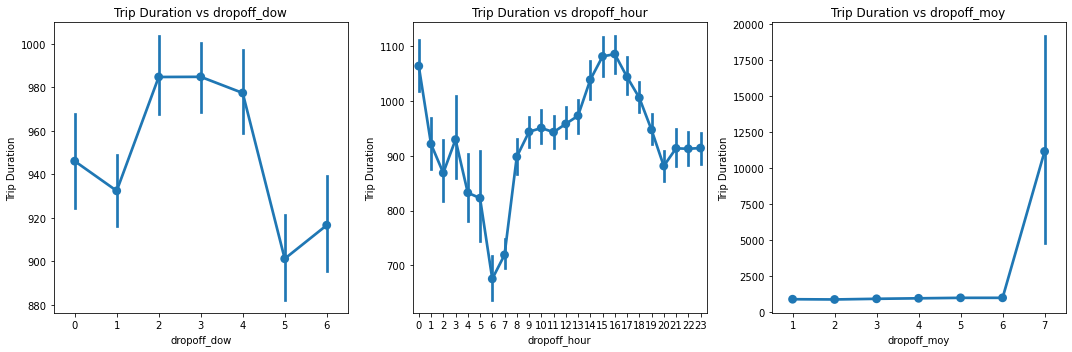

In [166]:
point_plt(data,dropoff_time)

In [ ]:
### 

## Bivariate Analysis: Categorical- Continuous 

In [173]:
data.select_dtypes(include='category').dtypes

id                     category
vendor_id              category
store_and_fwd_flag     category
pickup_time_of_day     category
dropoff_time_of_day    category
dtype: object

In [177]:
data.dtypes

id                     category
vendor_id              category
passenger_count           int64
pickup_longitude        float64
pickup_latitude         float64
dropoff_longitude       float64
dropoff_latitude        float64
store_and_fwd_flag     category
trip_duration             int64
pickup_dow                int64
pickup_moy                int64
pickup_date               int64
pickup_hour               int64
pickup_min                int64
dropoff_dow               int64
dropoff_moy               int64
dropoff_date              int64
dropoff_hour              int64
dropoff_min               int64
Distance                float64
pickup_time_of_day     category
dropoff_time_of_day    category
dtype: object

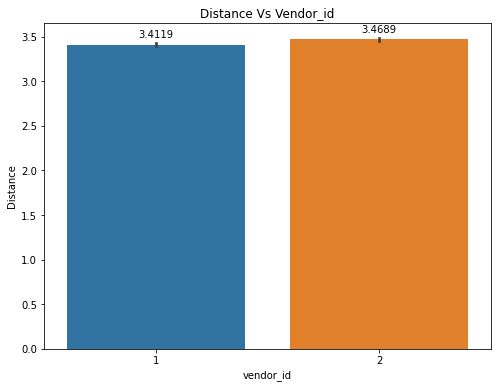

In [189]:
plt.figure(figsize=(8,6))
ax = sns.barplot(x=data['vendor_id'],y=data['Distance'])
for p in ax.patches:
    ax.annotate('{:.4f}'.format(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_y() + p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points',)
    plt.title('Distance Vs Vendor_id')

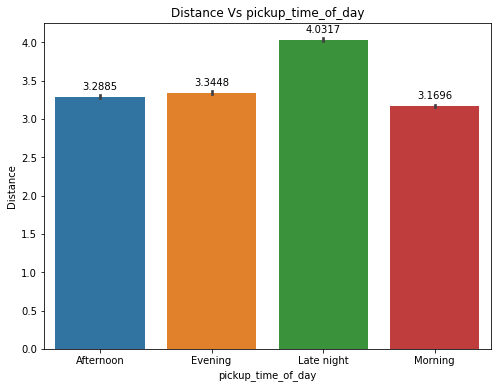

In [190]:
plt.figure(figsize=(8,6))
ax = sns.barplot(x=data['pickup_time_of_day'],y=data['Distance'])
for p in ax.patches:
    ax.annotate('{:.4f}'.format(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_y() + p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points',)
    plt.title('Distance Vs pickup_time_of_day')

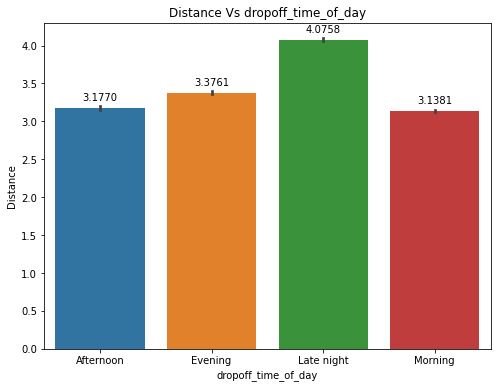

In [191]:
plt.figure(figsize=(8,6))
ax = sns.barplot(x=data['dropoff_time_of_day'],y=data['Distance'])
for p in ax.patches:
    ax.annotate('{:.4f}'.format(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_y() + p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points',)
    plt.title('Distance Vs dropoff_time_of_day')

In [ ]:
Continuous = ['Distance','trip_duration']
Category = ['passenger_count','vendor_id']
time = ['pickup_dow','pickup_moy']

In [94]:
Dis_time = ['Distance','trip_duration','passenger_count']
pickup_time = ['pickup_dow', 'pickup_hour','pickup_moy']
dropoff_time = ['dropoff_dow', 'dropoff_hour', 'dropoff_moy']
time = ['pickup_time_of_day','dropoff_time_of_day']

In [91]:
def line_plt(data, var):
    plt.figure(figsize=(15, 5))
    size = len(var)

    for j, i in enumerate(var, start=1):
        plt.subplot(1, size, j)
        sns.lineplot(x=i, y='Distance', data=data)
        plt.title(f'Distance vs {i}')
        plt.xlabel(i)
        plt.ylabel('Distance')

    plt.tight_layout()
    plt.show()

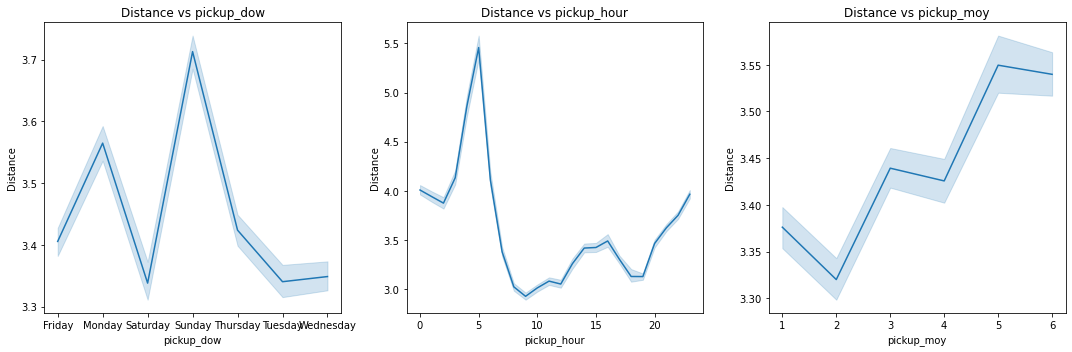

In [92]:
line_plt(data,pickup_time)

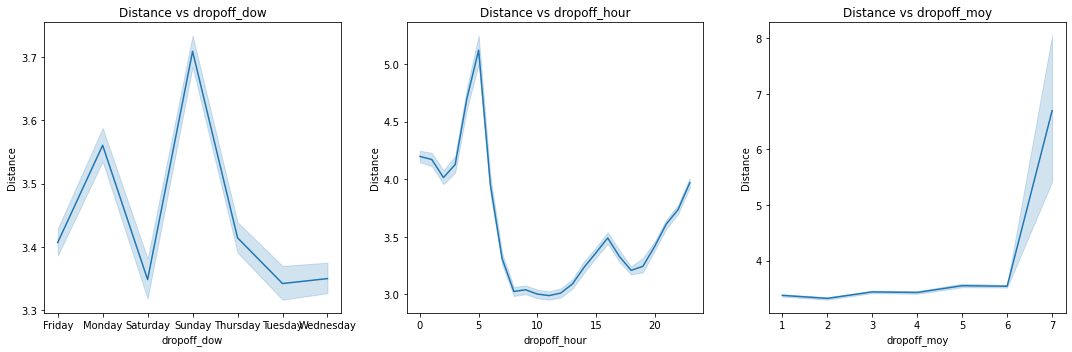

In [93]:
line_plt(data,dropoff_time)

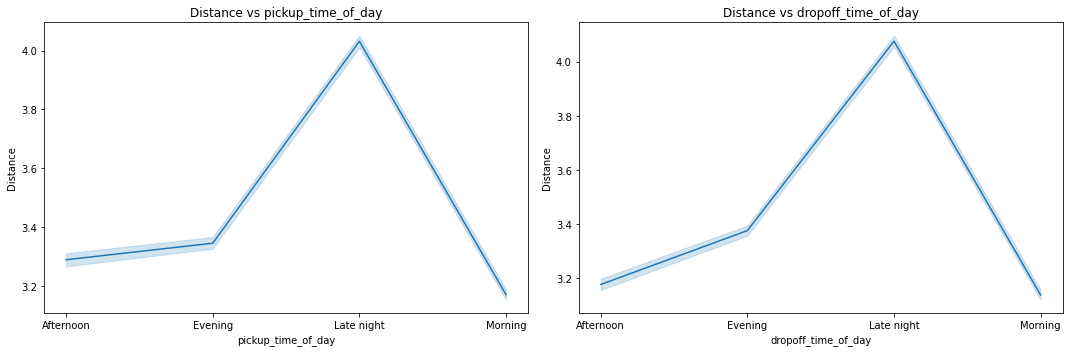

In [95]:
line_plt(data,time)